In [68]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [69]:
df = pd.read_csv("2 loan_approval_data.csv")

In [70]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

# Handle Mssing Values

In [71]:
categorical_columns = df.select_dtypes(include=["object"]).columns
numerical_columns = df.select_dtypes(include=["number"]).columns

In [72]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy="mean")
df[numerical_columns] = num_imp.fit_transform(df[numerical_columns])

In [73]:
num_imp = SimpleImputer(strategy="most_frequent")
df[categorical_columns] = num_imp.fit_transform(df[categorical_columns])

In [74]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


# EDA

Text(0.5, 1.0, 'Loan Approved Distribution')

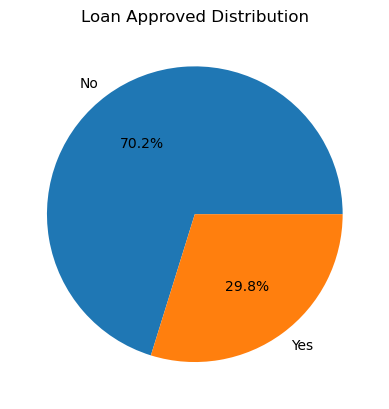

In [75]:
#how balanced our classes are?

classes_count = df["Loan_Approved"].value_counts()

plt.pie(classes_count, labels=["No","Yes"],autopct="%1.1f%%")
plt.title("Loan Approved Distribution")

[Text(0, 0, '722'), Text(0, 0, '278')]

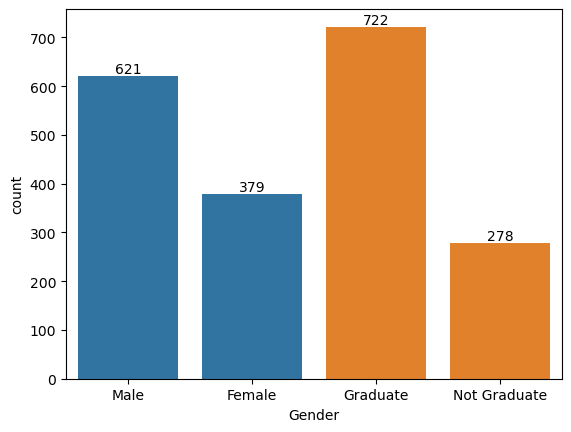

In [76]:
#analyzing categories

gender_count = df['Gender'].value_counts()
axis=sns.barplot(gender_count)
axis.bar_label(axis.containers[0])

edu_count = df['Education_Level'].value_counts()
axis_edu=sns.barplot(edu_count)
axis_edu.bar_label(axis_edu.containers[1])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

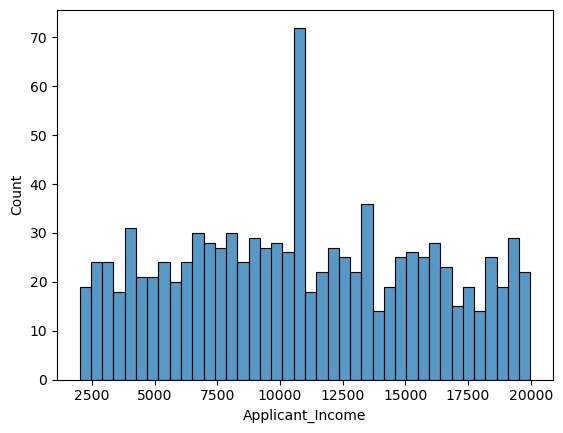

In [77]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    bins=40
)

<Axes: xlabel='Applicant_Income', ylabel='Loan_Approved'>

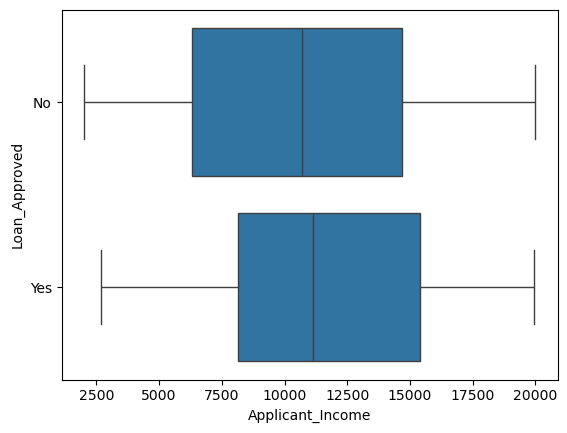

In [78]:
sns.boxplot(
    data=df,
    x="Applicant_Income",
    y="Loan_Approved"
)

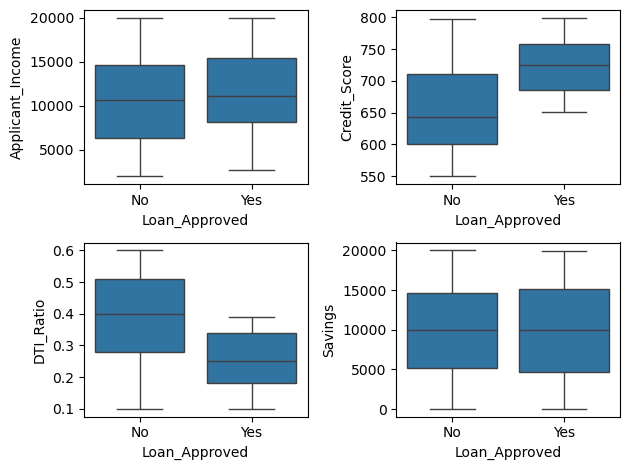

In [79]:
fig, axes = plt.subplots(2,2)

sns.boxplot(ax=axes[0,0], data=df, y="Applicant_Income", x="Loan_Approved")
sns.boxplot(ax=axes[0,1], data=df, y="Credit_Score", x="Loan_Approved")
sns.boxplot(ax=axes[1,0], data=df, y="DTI_Ratio", x="Loan_Approved")
sns.boxplot(ax=axes[1,1], data=df, y="Savings", x="Loan_Approved")

plt.tight_layout()


<Axes: xlabel='Credit_Score', ylabel='Count'>

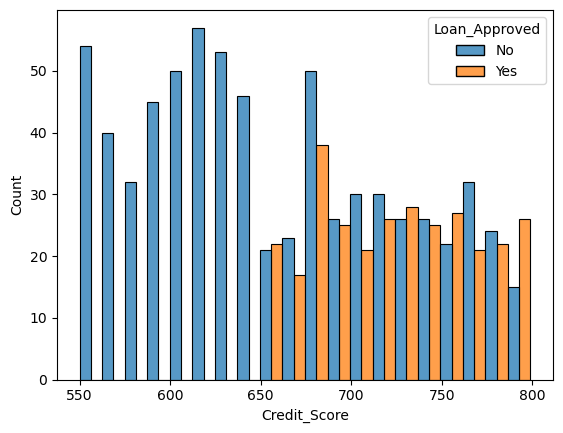

In [80]:
# credit_score vs loan_approved

sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

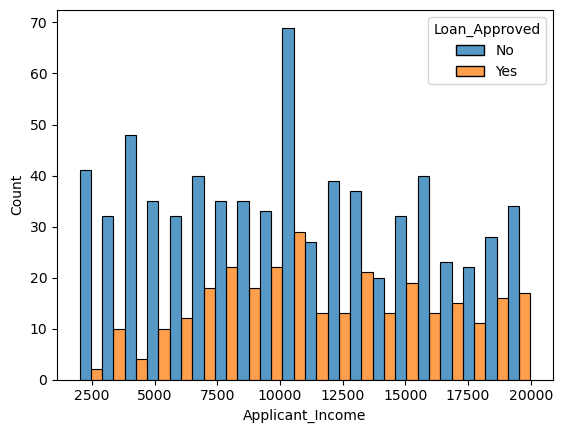

In [81]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

In [82]:
#removing applicant id

df = df.drop("Applicant_ID", axis=1)

In [83]:
df.head()
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [84]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le = LabelEncoder()

df["Education_Level"] = le.fit_transform(df["Education_Level"])

df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])



In [85]:
df.head()


,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [86]:
cols = ["Gender", "Marital_Status", "Loan_Purpose", "Property_Area", "Employment_Status", "Employer_Category"] 

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

encoded_data = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded_data, columns=ohe.get_feature_names_out(cols))

df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)


In [87]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

# Correlation Heatmap

<Axes: >

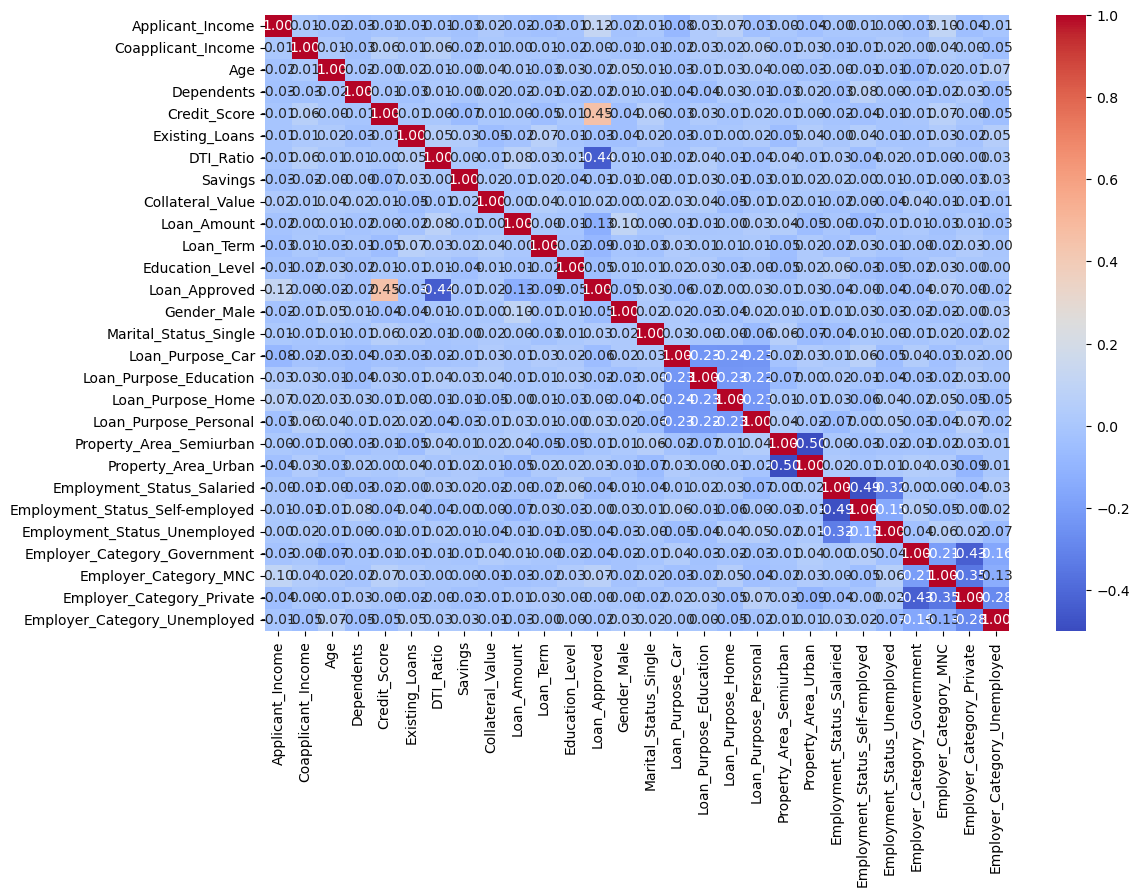

In [88]:
num_cols = df.select_dtypes(include=["number"])
corr_matrix = num_cols.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

In [89]:
num_cols.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

# Train-test-Split + Feature Scaling

In [90]:
X = df.drop("Loan_Approved", axis=1)
y = df["Loan_Approved"]

In [91]:
X.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [92]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [93]:
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
29,5890.000000,8041.0,31.000000,0.0,603.000000,0.000000,0.11,11906.0,8150.000000,29287.000000,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
535,4779.000000,529.0,50.000000,0.0,614.000000,0.000000,0.21,5369.0,5430.000000,14786.000000,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
695,10852.571579,8927.0,36.000000,0.0,584.000000,4.000000,0.22,3186.0,24802.792632,20522.825263,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
557,2384.000000,2113.0,39.971579,1.0,726.000000,4.000000,0.34,11882.0,48542.000000,13312.000000,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
836,5228.000000,5249.0,42.000000,1.0,676.033684,1.950526,0.18,17669.0,24802.792632,13906.000000,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [94]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(df.isnull().sum())

Applicant_Income                   0
Coapplicant_Income                 0
Age                                0
Dependents                         0
Credit_Score                       0
Existing_Loans                     0
DTI_Ratio                          0
Savings                            0
Collateral_Value                   0
Loan_Amount                        0
Loan_Term                          0
Education_Level                    0
Loan_Approved                      0
Gender_Male                        0
Marital_Status_Single              0
Loan_Purpose_Car                   0
Loan_Purpose_Education             0
Loan_Purpose_Home                  0
Loan_Purpose_Personal              0
Property_Area_Semiurban            0
Property_Area_Urban                0
Employment_Status_Salaried         0
Employment_Status_Self-employed    0
Employment_Status_Unemployed       0
Employer_Category_Government       0
Employer_Category_MNC              0
Employer_Category_Private          0
E

# Train and Evaluate Models

In [95]:
#logistic regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

#Evaluation
print("Logistic Regression Model Evaluation:")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Model Evaluation:
Precision: 0.7833333333333333
Recall: 0.7704918032786885
F1-Score: 0.7768595041322314
Accuracy: 0.865
Confusion Matrix:
[[126  13]
 [ 14  47]]
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.90       139
           1       0.78      0.77      0.78        61

    accuracy                           0.86       200
   macro avg       0.84      0.84      0.84       200
weighted avg       0.86      0.86      0.86       200



In [98]:
#knn regression

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

log_model = KNeighborsClassifier(n_neighbors=5)
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

#Evaluation
print("K-Nearest Neighbors Model Evaluation:")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

K-Nearest Neighbors Model Evaluation:
Precision: 0.6274509803921569
Recall: 0.5245901639344263
F1-Score: 0.5714285714285714
Accuracy: 0.76
Confusion Matrix:
[[120  19]
 [ 29  32]]
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.86      0.83       139
           1       0.63      0.52      0.57        61

    accuracy                           0.76       200
   macro avg       0.72      0.69      0.70       200
weighted avg       0.75      0.76      0.75       200



In [99]:
#Naive Bayes Classification

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

log_model = GaussianNB()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

#Evaluation
print("Naive Bayes Model Evaluation:")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Naive Bayes Model Evaluation:
Precision: 0.8035714285714286
Recall: 0.7377049180327869
F1-Score: 0.7692307692307693
Accuracy: 0.865
Confusion Matrix:
[[128  11]
 [ 16  45]]
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.92      0.90       139
           1       0.80      0.74      0.77        61

    accuracy                           0.86       200
   macro avg       0.85      0.83      0.84       200
weighted avg       0.86      0.86      0.86       200



# Best Model Selection => Naive Bayes Classifier performed the best with highest precision

# Feature Engineering

In [102]:
#Add or transform features

df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2
df["Credit_score_sq"] = df["Credit_Score"] ** 2

#neutralize from skewness
# df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"])

X = df.drop(columns = ["Loan_Approved", "Credit_Score", "DTI_Ratio"])
y = df["Loan_Approved"]

#Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
#scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [103]:
#logistic regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

#Evaluation
print("Logistic Regression Model Evaluation:")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Model Evaluation:
Precision: 0.7846153846153846
Recall: 0.8360655737704918
F1-Score: 0.8095238095238095
Accuracy: 0.88
Confusion Matrix:
[[125  14]
 [ 10  51]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.91       139
           1       0.78      0.84      0.81        61

    accuracy                           0.88       200
   macro avg       0.86      0.87      0.86       200
weighted avg       0.88      0.88      0.88       200



In [104]:
#knn regression

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

log_model = KNeighborsClassifier(n_neighbors=5)
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

#Evaluation
print("K-Nearest Neighbors Model Evaluation:")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

K-Nearest Neighbors Model Evaluation:
Precision: 0.6730769230769231
Recall: 0.5737704918032787
F1-Score: 0.6194690265486725
Accuracy: 0.785
Confusion Matrix:
[[122  17]
 [ 26  35]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       139
           1       0.67      0.57      0.62        61

    accuracy                           0.79       200
   macro avg       0.75      0.73      0.73       200
weighted avg       0.78      0.79      0.78       200



In [105]:
#Naive Bayes Classification

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

log_model = GaussianNB()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

#Evaluation
print("Naive Bayes Model Evaluation:")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))


Naive Bayes Model Evaluation:
Precision: 0.8113207547169812
Recall: 0.7049180327868853
F1-Score: 0.7543859649122807
Accuracy: 0.86
Confusion Matrix:
[[129  10]
 [ 18  43]]
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       139
           1       0.81      0.70      0.75        61

    accuracy                           0.86       200
   macro avg       0.84      0.82      0.83       200
weighted avg       0.86      0.86      0.86       200



# Naive Bayes gives the Best : Precision (not allowed hish risk customers)

# Logistic Regression gives the Best : Other Parameters